<a href="https://colab.research.google.com/github/Vermont-Complex-Systems/storywrangler/blob/wiki-hedo/notebooks/getting_started_sdk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U storywrangler

In [2]:
# local packages
from storywrangler import Storywrangler

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

In [3]:
import storywrangler
print(storywrangler.__version__)

0.0.11


In [4]:
client=Storywrangler()

## Exploring datasets

In [5]:
r = client.registry

In [6]:
# displaying a client shows what its route serves — here, the catalog itself
r

Registry — 18 datasets:
  babynames/ngrams                     latest   Baby names by popularity, year, and location with entity ...
  open-academic-analytics/academic-research-groups latest   UVM faculty roster with OpenAlex IDs, departments, and re...
  open-academic-analytics/authors      latest   Per-author summary: current career age, last publication ...
  open-academic-analytics/coauthors    latest   UVM faculty coauthor relationships with age categories an...
  open-academic-analytics/papers       latest   UVM faculty papers with UMAP embeddings, citation metrics...
  open-academic-analytics/training     latest   UVM faculty collaboration training data in wide format wi...
  reddit/ngrams                        latest   Reddit ngrams
  scisciDB/field-topic-metrics         latest   Precomputed paper counts by S2 field of study, OpenAlex p...
  scisciDB/field-venue-metrics         latest   Precomputed paper counts by S2 field of study, venue, yea...
  twitter/ngrams              

In [7]:
# when applicable, dataframe is callable
r.list().df().head()

,catalog,domain,dataset_id,version,data_location,data_format,description,endpoint_schema,level_order,filter_values,created_at,updated_at
0,vcsi,babynames,ngrams,latest,[/users/j/s/jstonge1/babynames/metadata.duckla...,parquet,"Baby names by popularity, year, and location w...","{'type': 'types-counts', 'type_column': None, ...",None,"{'sex': ['F', 'M']}",2026-04-07T16:35:14.417279+00:00,2026-07-17T15:03:23.490632+00:00
1,vcsi,open-academic-analytics,academic-research-groups,latest,/users/j/s/jstonge1/academic-research-groups/a...,parquet,"UVM faculty roster with OpenAlex IDs, departme...",None,None,None,2026-04-07T16:50:31.443578+00:00,2026-04-20T17:47:35.246812+00:00
2,vcsi,open-academic-analytics,authors,latest,/netfiles/compethicslab/open-academic-analytic...,parquet,"Per-author summary: current career age, last p...",None,None,None,2026-04-07T16:47:46.316179+00:00,2026-04-07T16:47:46.320173+00:00
3,vcsi,open-academic-analytics,coauthors,latest,/netfiles/compethicslab/open-academic-analytic...,parquet,UVM faculty coauthor relationships with age ca...,None,None,None,2026-04-07T16:47:46.299656+00:00,2026-04-07T16:47:46.305212+00:00
4,vcsi,open-academic-analytics,papers,latest,/netfiles/compethicslab/open-academic-analytic...,parquet,"UVM faculty papers with UMAP embeddings, citat...",None,None,None,2026-04-07T16:47:46.289511+00:00,2026-04-07T16:47:46.295242+00:00


- the `sdk` matches the [api-reference](https://storywrangler.uvm.edu/api-reference), e.g. [https://api.storywrangler.uvm.edu/registry/](https://storywrangler.uvm.edu/api-reference/registry/) -> `client.registry.list()`.
- you get the metadata for each dataset; see [here](https://storywrangler.uvm.edu/api-reference/registry/post-registry-register) for description of all the fields (also we maintain [storywrangler specification](https://storywrangler.uvm.edu/specification#37-dataset-registration-schema), an open source specs to discuss the schema).

## Deep dive `babynames` dataset

In [8]:
# create a dataset object
bb = client.dataset("babynames", "ngrams")
# raw metadata also works: client.registry.get("babynames", "ngrams")

In [9]:
# looking up registered transforms
bb.meta['transform']

{'time_dimension': 'year',
 'filter_dimensions': ['sex'],
 'time_partitions': None,
 'hash_bucket': None,
 'hash_algorithm': 'murmur3_32',
 'hash_seed': 0}

In [10]:
# lookuping filter values
bb.meta['filter_values']['sex']

['F', 'M']

In [11]:
# the manifest, or what metadata is available per country
# useful to specify query by filter
bb.availability

{'quebec': {'min': '1980', 'max': '2024', 'types': 1700},
 'united_states': {'min': '1880', 'max': '2024', 'types': 29225}}

In [12]:
# entity -> entity local_id
bb.adapter

[{'local_id': 'united_states',
  'entity_id': 'wikidata:Q30',
  'entity_name': 'United States',
  'entity_ids': ['iso:US', 'local:babynames:united_states']},
 {'local_id': 'quebec',
  'entity_id': 'wikidata:Q176',
  'entity_name': 'Quebec',
  'entity_ids': ['iso:CA-QC', 'local:babynames:quebec']}]

In [13]:
# same mapping as a table
bb.adapter.df()

,local_id,entity_id,entity_name,entity_ids
0,united_states,wikidata:Q30,United States,"[iso:US, local:babynames:united_states]"
1,quebec,wikidata:Q176,Quebec,"[iso:CA-QC, local:babynames:quebec]"


In [14]:
# top names for two systems at once;
# limit uses the vocabulary ceiling from availability
ngram_data = bb.top_ngrams(
    entity="wikidata:Q30",
    dates=1968, dates2=2018,
    sex="M", limit=bb.availability["united_states"]["types"],
)
list(ngram_data)

['1968', '2018', 'metadata']

In [22]:
# all ngrams data are in the standards "types-count" format
ngram_data.df()

,types,counts,system
0,Michael,81974.0,1968
1,David,63683.0,1968
2,John,60906.0,1968
3,James,60666.0,1968
4,Robert,58186.0,1968
...,...,...,...
18850,Zandon,5.0,2018
18851,Zaviel,5.0,2018
18852,Zeev,5.0,2018
18853,Zichen,5.0,2018


## Wikimedia

In [23]:
wiki = client.dataset("wikimedia", "ngrams")
wiki.endpoints

{'/wikimedia/top-ngrams': {'summary': 'Get Top Ngrams', 'dataset': 'ngrams'},
 '/wikimedia/revisions': {'summary': 'List Revision Articles',
  'dataset': 'revisions'},
 '/wikimedia/revisions/{identifier}': {'summary': 'Get Revision Deltas',
  'dataset': 'revisions'},
 '/wikimedia/term-series': {'summary': 'Term Series', 'dataset': 'ngrams'},
 '/wikimedia/term-series/batch': {'summary': 'Term Series Batch',
  'dataset': 'ngrams'},
 '/wikimedia/precomputed-rtd': {'summary': 'Precomputed Rtd',
  'dataset': 'precomputed_rtd'},
 '/wikimedia/semantic-timeseries': {'summary': 'Semantic Timeseries',
  'dataset': 'semantic-timeseries'},
 '/wikimedia/semantic-ngrams': {'summary': 'Semantic Ngrams',
  'dataset': 'semantic-ngrams'}}

In [24]:
ts1 = wiki.term_series(
    "Trump", entity="wikidata:Q30", window=365
    ).df().set_index("date").assign(name=lambda x: "Trump")[['rank', 'name']]
ts2 = wiki.term_series(
    "Harris", entity="wikidata:Q30", window=365
    ).df().set_index("date").assign(name=lambda x: "Harris")[['rank', 'name']]

In [25]:
ts_df=pd.merge(ts1, ts2, on="date", suffixes=[" Trump", " Harris"])

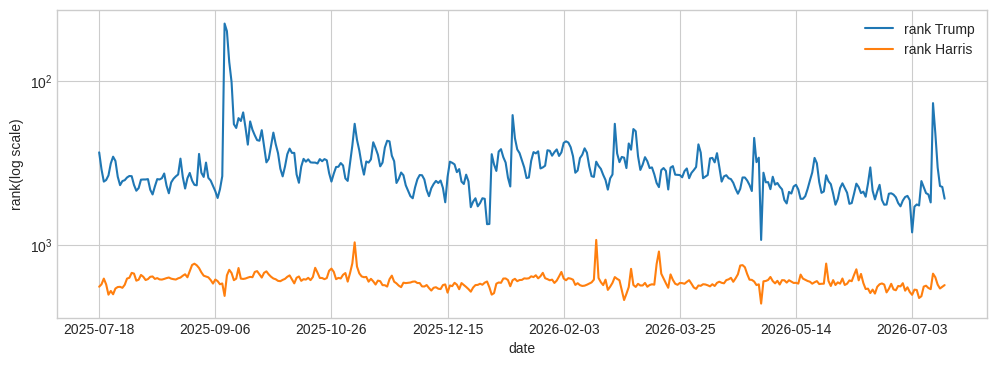

In [26]:
ax=ts_df.plot(logy=True, figsize=(12,4));
plt.gca().invert_yaxis()
ax.set_ylabel("rank(log scale)");

- easy to customize plot using `pandas` and `matplotlib` combo.

In [28]:
#try the same plot but with bigrams!

## Batch endpoint

In [37]:
%%time
wiki.term_series("Trump", entity="United States", window=30, include_articles=False).df().head()
wiki.term_series("Harris", entity="United States", window=30, include_articles=False).df().head()
wiki.term_series("Vance", entity="United States", window=30, include_articles=False).df().head()
wiki.term_series("Walz", entity="United States", window=30, include_articles=False).df().head()

CPU times: user 14.7 ms, sys: 1.77 ms, total: 16.5 ms
Wall time: 1.34 s


,date,counts,rank,freq
0,2026-06-18,335513,31091,0.000002
1,2026-06-19,363019,29461,0.000002
2,2026-06-20,338713,31033,0.000002
3,2026-06-21,343043,33089,0.000001
4,2026-06-22,413597,31140,0.000002


In [38]:
# scales better
%time wiki.term_series_batch(["Trump", "Harris", "Vance", "Walz"], entity="United States", window=30, include_articles=False).df().head()

CPU times: user 13.9 ms, sys: 143 µs, total: 14 ms
Wall time: 703 ms


,date,counts,rank,freq,type
0,2026-06-18,43349132,472,0.000194,Trump
1,2026-06-19,47306189,430,0.000211,Trump
2,2026-06-20,38342134,531,0.000171,Trump
3,2026-06-21,39356641,568,0.000160,Trump
4,2026-06-22,42927942,567,0.000158,Trump


## Domain objects & dynamic routes

In [ ]:
# one-argument scoping works when a domain has a single dataset;
# displaying it lists the endpoints (mirrors GET /{domain})
tw = client.dataset("twitter")
tw

In [ ]:
# multi-dataset domains ask you to choose — errors carry the fix
try:
    client.dataset("wikimedia").availability
except ValueError as e:
    print(e)

In [ ]:
# any route is callable by its guessable name (underscores map to dashes)
wiki.revisions(limit=2)["articles"]

## The escape hatch & platform status

In [ ]:
# routes without a dedicated method are one .get() away
client.get("/open-academic-analytics/authors")[:1]

In [ ]:
# component versions and dataset health
client.version(), client.health.status()["summary"]